Ten fragment wylicza dla całej piosenki leading... to nie do końca zadziała. w różnych punktach różne instrumenty grają główne skrzypce.

In [1]:
import pretty_midi

nazwa_pliku = 'music/Age_of_Empires_2_Menu_Music.mid' # Podmień na nazwę swojego pliku

# --- CZĘŚĆ 1: ANALIZA (pretty_midi) ---
print("--- ROZPOCZYNAM ANALIZĘ ---")
utwor = pretty_midi.PrettyMIDI(nazwa_pliku)
instrument = utwor.instruments[0]

max_sredni_pitch = 0
max_sredni_pitch_index = None

for i, instrument in enumerate(utwor.instruments):
    print(f"Ścieżka {i}: {instrument.name} - liczba nut: {len(instrument.notes)}")
    # Ignorujemy perkusję i ścieżki posiadające zbyt mało nut (np. pojedyncze efekty dźwiękowe)
    if instrument.is_drum or len(instrument.notes) < 30:
        continue 
        
    suma_pitch = sum(nuta.pitch for nuta in instrument.notes)
    sredni_pitch = suma_pitch / len(instrument.notes)
    
    # Szukamy ścieżki, która operuje w najwyższym rejestrze
    if sredni_pitch > max_sredni_pitch:
        max_sredni_pitch = sredni_pitch
        max_sredni_pitch_index = i
    

# Skrypt automatycznie wybrał linię melodyczną bez ręcznego wskazywania indeksu
print(f"Wybrano ścieżkę: {utwor.instruments[max_sredni_pitch_index].name} ({max_sredni_pitch_index}) ze średnim rejestrem {max_sredni_pitch:.2f}")

--- ROZPOCZYNAM ANALIZĘ ---
Ścieżka 0: MIDI Version - liczba nut: 46
Ścieżka 1: MIDI Version - liczba nut: 100
Ścieżka 2: MIDI Version - liczba nut: 207
Ścieżka 3: MIDI Version - liczba nut: 21
Ścieżka 4: MIDI Version - liczba nut: 364
Ścieżka 5: MIDI Version - liczba nut: 16
Ścieżka 6: MIDI Version - liczba nut: 158
Ścieżka 7: MIDI Version - liczba nut: 147
Ścieżka 8: MIDI Version - liczba nut: 6
Ścieżka 9: MIDI Version - liczba nut: 35
Ścieżka 10: MIDI Version - liczba nut: 47
Ścieżka 11: MIDI Version - liczba nut: 44
Ścieżka 12: MIDI Version - liczba nut: 42
Ścieżka 13: MIDI Version - liczba nut: 21
Ścieżka 14: MIDI Version - liczba nut: 25
Ścieżka 15: MIDI Version - liczba nut: 1
Wybrano ścieżkę: MIDI Version (10) ze średnim rejestrem 73.23


In [2]:
fs_interval = 50
piano_roll = utwor.get_piano_roll(fs=100)  # 100 klatek na sekundę
print(f"Piano roll shape: {piano_roll.shape}")

Piano roll shape: (128, 6046)


In [3]:

highest_pitches = []
for i in range(0, piano_roll.shape[1], fs_interval):
    print(f"--- Odcinek {i // fs_interval + 1} ---")

    found_flag = False
    for pitch in range(60, 128)[::-1]:
        if not piano_roll[pitch, i:i+fs_interval].any():
            continue

        if piano_roll[pitch, i:i+fs_interval].sum() < 2000:
            continue

        print(f"Pitch {pitch} jest aktywny w tej sekundzie.")
        highest_pitches.append(pitch)
        found_flag = True
        break
    
    if not found_flag:
        print("Brak aktywnych pitchy w tej sekundzie.")
        highest_pitches.append(None)

highest_pitches

--- Odcinek 1 ---
Pitch 93 jest aktywny w tej sekundzie.
--- Odcinek 2 ---
Pitch 93 jest aktywny w tej sekundzie.
--- Odcinek 3 ---
Pitch 93 jest aktywny w tej sekundzie.
--- Odcinek 4 ---
Pitch 93 jest aktywny w tej sekundzie.
--- Odcinek 5 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 6 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 7 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 8 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 9 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 10 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 11 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 12 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 13 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 14 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 15 ---
Pitch 86 jest aktywny w tej sekundzie.
--- Odcinek 16 ---
Pitch 79 jest aktywny w tej sekundzie.
--- Odcinek 17 ---
Pitch 79 jest aktywny w tej sekundzie.
--- Odcinek 18 ---
Pitc

[93,
 93,
 93,
 93,
 86,
 86,
 86,
 86,
 86,
 86,
 86,
 86,
 86,
 86,
 86,
 79,
 79,
 81,
 86,
 86,
 86,
 86,
 86,
 86,
 86,
 86,
 76,
 76,
 77,
 74,
 74,
 74,
 74,
 79,
 67,
 82,
 81,
 79,
 75,
 74,
 79,
 79,
 84,
 82,
 81,
 78,
 79,
 79,
 79,
 79,
 79,
 74,
 79,
 74,
 79,
 79,
 79,
 84,
 82,
 81,
 79,
 79,
 81,
 81,
 84,
 83,
 83,
 83,
 83,
 81,
 81,
 81,
 83,
 83,
 83,
 83,
 76,
 81,
 81,
 84,
 83,
 83,
 83,
 83,
 83,
 83,
 84,
 83,
 81,
 81,
 81,
 81,
 69,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [4]:
# Run-Length Encoding (RLE) dla najwyższych pitchy
rle_result = []
current_pitch = None
current_count = 0

# KCTODO te none nie działają...
for pitch in highest_pitches:
    if pitch == current_pitch:
        current_count += 1
    else:
        if current_pitch is not None:
            rle_result.append((current_pitch, current_count))
        else:
            rle_result.append((None, current_count))
            current_pitch = None
        current_pitch = pitch
        current_count = 1

# Dodaj ostatnią grupę
if current_pitch is not None:
    rle_result.append((current_pitch, current_count))

rle_result = rle_result[1:]  # Usuwamy pierwszą grupę, która jest None

print("Run-Length Encoding (RLE) wynik:")
for pitch, count in rle_result:
    print(f"Pitch: {pitch if pitch is not None else 'None'}, Count: {count}")
    # print(f"Pitch: {pretty_midi.note_number_to_name(pitch) if pitch is not None else 'None'}, Count: {count}")

Run-Length Encoding (RLE) wynik:
Pitch: 93, Count: 4
Pitch: 86, Count: 11
Pitch: 79, Count: 2
Pitch: 81, Count: 1
Pitch: 86, Count: 8
Pitch: 76, Count: 2
Pitch: 77, Count: 1
Pitch: 74, Count: 4
Pitch: 79, Count: 1
Pitch: 67, Count: 1
Pitch: 82, Count: 1
Pitch: 81, Count: 1
Pitch: 79, Count: 1
Pitch: 75, Count: 1
Pitch: 74, Count: 1
Pitch: 79, Count: 2
Pitch: 84, Count: 1
Pitch: 82, Count: 1
Pitch: 81, Count: 1
Pitch: 78, Count: 1
Pitch: 79, Count: 5
Pitch: 74, Count: 1
Pitch: 79, Count: 1
Pitch: 74, Count: 1
Pitch: 79, Count: 3
Pitch: 84, Count: 1
Pitch: 82, Count: 1
Pitch: 81, Count: 1
Pitch: 79, Count: 2
Pitch: 81, Count: 2
Pitch: 84, Count: 1
Pitch: 83, Count: 4
Pitch: 81, Count: 3
Pitch: 83, Count: 4
Pitch: 76, Count: 1
Pitch: 81, Count: 2
Pitch: 84, Count: 1
Pitch: 83, Count: 6
Pitch: 84, Count: 1
Pitch: 83, Count: 1
Pitch: 81, Count: 4
Pitch: 69, Count: 1


Pierwsza pochodna najwyższych pitchy:
Odcinek 2: 0
Odcinek 3: 0
Odcinek 4: 0
Odcinek 5: -7
Odcinek 6: 0
Odcinek 7: 0
Odcinek 8: 0
Odcinek 9: 0
Odcinek 10: 0
Odcinek 11: 0
Odcinek 12: 0
Odcinek 13: 0
Odcinek 14: 0
Odcinek 15: 0
Odcinek 16: -7
Odcinek 17: 0
Odcinek 18: 2
Odcinek 19: 5
Odcinek 20: 0
Odcinek 21: 0
Odcinek 22: 0
Odcinek 23: 0
Odcinek 24: 0
Odcinek 25: 0
Odcinek 26: 0
Odcinek 27: -10
Odcinek 28: 0
Odcinek 29: 1
Odcinek 30: -3
Odcinek 31: 0
Odcinek 32: 0
Odcinek 33: 0
Odcinek 34: 5
Odcinek 35: -12
Odcinek 36: 15
Odcinek 37: -1
Odcinek 38: -2
Odcinek 39: -4
Odcinek 40: -1
Odcinek 41: 5
Odcinek 42: 0
Odcinek 43: 5
Odcinek 44: -2
Odcinek 45: -1
Odcinek 46: -3
Odcinek 47: 1
Odcinek 48: 0
Odcinek 49: 0
Odcinek 50: 0
Odcinek 51: 0
Odcinek 52: -5
Odcinek 53: 5
Odcinek 54: -5
Odcinek 55: 5
Odcinek 56: 0
Odcinek 57: 0
Odcinek 58: 5
Odcinek 59: -2
Odcinek 60: -1
Odcinek 61: -2
Odcinek 62: 0
Odcinek 63: 2
Odcinek 64: 0
Odcinek 65: 3
Odcinek 66: -1
Odcinek 67: 0
Odcinek 68: 0
Odcinek 69:

Matplotlib is building the font cache; this may take a moment.


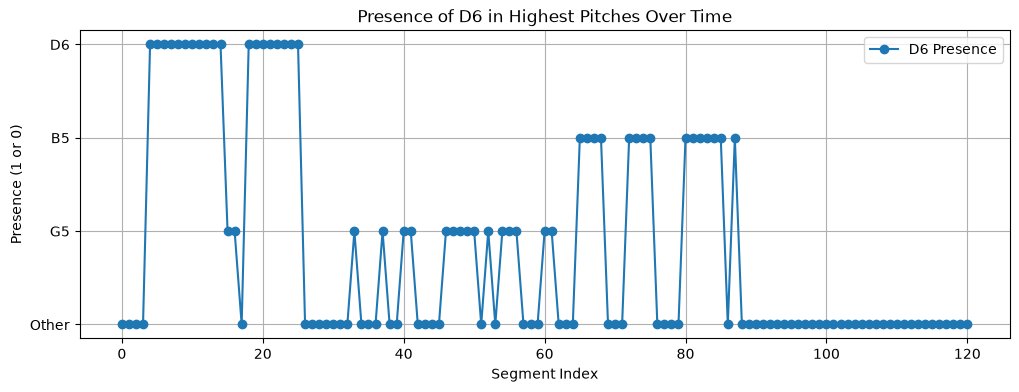

In [5]:
# first derivative
derivative_result = []
for i in range(1, len(highest_pitches)):
    if highest_pitches[i] is None or highest_pitches[i-1] is None:
        derivative_result.append(None)
    else:
        derivative_result.append(highest_pitches[i] - highest_pitches[i-1])
print("Pierwsza pochodna najwyższych pitchy:")
for i, derivative in enumerate(derivative_result):
    print(f"Odcinek {i + 2}: {derivative if derivative is not None else 'None'}")

# metryka - redundancja melodyczna
total_segments = len(highest_pitches)
lre_pitches = len(rle_result)
redundancy_metric = lre_pitches / total_segments if total_segments > 0 else 0
print(f"Redundancja melodyczna: {redundancy_metric:.2f}")

# metryka - Event Mass
event_mass = sorted([(pitch, count) for pitch, count in rle_result if pitch is not None], key=lambda x: x[1], reverse=True)
print("Event Mass (posortowane):")
for pitch, count in event_mass[:5]:
    print(f"Pitch: {pretty_midi.note_number_to_name(pitch)}, Count: {count}")

# show on plot where pitch is D6
import matplotlib.pyplot as plt
d6_pitch = pretty_midi.note_name_to_number('D6')
b5_pitch = pretty_midi.note_name_to_number('B5')
g5_pitch = pretty_midi.note_name_to_number('G5')
presence_dict = {d6_pitch: 3,
b5_pitch: 2,
g5_pitch: 1}

presences = [presence_dict.get(pitch, 0) for pitch in highest_pitches]
plt.figure(figsize=(12, 4))
plt.plot(presences, label='D6 Presence', marker='o')
plt.title('Presence of D6 in Highest Pitches Over Time')
plt.xlabel('Segment Index')
plt.ylabel('Presence (1 or 0)')
plt.yticks([0, 1, 2, 3], ['Other', 'G5', 'B5', 'D6'])
plt.legend()
plt.grid()
plt.show()

In [6]:
# searching for n-grams of pitch sequences
from collections import Counter

rle_flat = [pitch for pitch, count in rle_result if pitch is not None]

n = 2  # Długość n-gramu
ngrams = [tuple(rle_flat[i:i+n]) for i in range(len(rle_flat) - n + 1)]
ngram_counts = Counter(ngrams)
print("Najczęstsze n-gramy (pitch sequences):")
for ngram, count in ngram_counts.most_common(10):
    print(f"N-gram: {[pretty_midi.note_number_to_name(x) for x in ngram]}, Count: {count}")

n = 3  # Długość n-gramu
ngrams = [tuple(rle_flat[i:i+n]) for i in range(len(rle_flat) - n + 1)]
ngram_counts = Counter(ngrams)
print("Najczęstsze n-gramy (pitch sequences):")
for ngram, count in ngram_counts.most_common(10):
    print(f"N-gram: {[pretty_midi.note_number_to_name(x) for x in ngram]}, Count: {count}")


n = 4  # Długość n-gramu
ngrams = [tuple(rle_flat[i:i+n]) for i in range(len(rle_flat) - n + 1)]
ngram_counts = Counter(ngrams)
print("Najczęstsze n-gramy (pitch sequences):")
for ngram, count in ngram_counts.most_common(10):
    print(f"N-gram: {[pretty_midi.note_number_to_name(x) for x in ngram]}, Count: {count}")



n = 5  # Długość n-gramu
ngrams = [tuple(rle_flat[i:i+n]) for i in range(len(rle_flat) - n + 1)]
ngram_counts = Counter(ngrams)
print("Najczęstsze n-gramy (pitch sequences):")
for ngram, count in ngram_counts.most_common(10):
    print(f"N-gram: {[pretty_midi.note_number_to_name(x) for x in ngram]}, Count: {count}")

# Teraz interwały są zależne od transpozycji, więc możemy je obliczyć na podstawie różnic między kolejnymi pitchami
intervals = []
for i in range(1, len(rle_flat)):
    if rle_flat[i] is not None and rle_flat[i-1] is not None:
        interval = rle_flat[i] - rle_flat[i-1]
        intervals.append(interval % 12)

interval_counts = Counter(intervals)
print("Najczęstsze interwały między najwyższymi pitchami:")
for interval, count in interval_counts.most_common(10):
    print(f"Interwał: {interval} semitones, Count: {count}")

n = 2  # Długość n-gramu interwałów
interval_ngrams = [tuple(intervals[i:i+n]) for i in range(len(intervals) - n + 1)]
interval_ngram_counts = Counter(interval_ngrams)
print("Najczęstsze n-gramy interwałów:")
for ngram, count in interval_ngram_counts.most_common(10):
    print(f"N-gram interwałów: {ngram}, Count: {count}")

n = 3  # Długość n-gramu interwałów
interval_ngrams = [tuple(intervals[i:i+n]) for i in range(len(intervals) - n + 1)]
interval_ngram_counts = Counter(interval_ngrams)
print("Najczęstsze n-gramy interwałów:")
for ngram, count in interval_ngram_counts.most_common(10):
    print(f"N-gram interwałów: {ngram}, Count: {count}")

n = 4  # Długość n-gramu interwałów
interval_ngrams = [tuple(intervals[i:i+n]) for i in range(len(intervals) - n + 1)]
interval_ngram_counts = Counter(interval_ngrams)
print("Najczęstsze n-gramy interwałów:")
for ngram, count in interval_ngram_counts.most_common(10):
    print(f"N-gram interwałów: {ngram}, Count: {count}")

n = 5  # Długość n-gramu interwałów
interval_ngrams = [tuple(intervals[i:i+n]) for i in range(len(intervals) - n + 1)]
interval_ngram_counts = Counter(interval_ngrams)
print("Najczęstsze n-gramy interwałów:")
for ngram, count in interval_ngram_counts.most_common(10):
    print(f"N-gram interwałów: {ngram}, Count: {count}")

# entropia interwałów
import math
total_intervals = sum(interval_counts.values())
interval_entropy = -sum((count / total_intervals) * math.log2(count / total_intervals) for count in interval_counts.values())
print(f"Entropia interwałów: {interval_entropy:.4f} bits")

Najczęstsze n-gramy (pitch sequences):
N-gram: ['D5', 'G5'], Count: 4
N-gram: ['A#5', 'A5'], Count: 3
N-gram: ['C6', 'B5'], Count: 3
N-gram: ['G5', 'A5'], Count: 2
N-gram: ['A5', 'G5'], Count: 2
N-gram: ['G5', 'C6'], Count: 2
N-gram: ['C6', 'A#5'], Count: 2
N-gram: ['G5', 'D5'], Count: 2
N-gram: ['A5', 'C6'], Count: 2
N-gram: ['B5', 'A5'], Count: 2
Najczęstsze n-gramy (pitch sequences):
N-gram: ['A#5', 'A5', 'G5'], Count: 2
N-gram: ['D5', 'G5', 'C6'], Count: 2
N-gram: ['G5', 'C6', 'A#5'], Count: 2
N-gram: ['C6', 'A#5', 'A5'], Count: 2
N-gram: ['G5', 'D5', 'G5'], Count: 2
N-gram: ['A5', 'C6', 'B5'], Count: 2
N-gram: ['C6', 'B5', 'A5'], Count: 2
N-gram: ['A6', 'D6', 'G5'], Count: 1
N-gram: ['D6', 'G5', 'A5'], Count: 1
N-gram: ['G5', 'A5', 'D6'], Count: 1
Najczęstsze n-gramy (pitch sequences):
N-gram: ['D5', 'G5', 'C6', 'A#5'], Count: 2
N-gram: ['G5', 'C6', 'A#5', 'A5'], Count: 2
N-gram: ['A6', 'D6', 'G5', 'A5'], Count: 1
N-gram: ['D6', 'G5', 'A5', 'D6'], Count: 1
N-gram: ['G5', 'A5', 'D6

Możliwe że trzeba analizy wykonać z osobna. AOE powinno mieć entropię lt 2.6 as per chatgpt